# SafeFam — SMSData.ipynb

**실행 전 순서 확인:**
```
1. python train_sms.py    # 학습 → phishing_model_artifact.pkl
2. 이 노트북 실행          # 시각화 + 검증
```

> 학습 코드는 `train_sms.py`로 분리됨. 이 노트북은 시각화 전용이며,
> 정규화/피처 추출 로직을 복제하지 않고 `train_sms.py`를 모듈로 import해서 씁니다
> (복제해두면 원본이 수정될 때 노트북만 낡은 채로 남는 문제가 생기기 쉬움).

**파일 구조:**
```
SMSModel/
├── train_sms.py                  # 학습 스크립트
├── SMSData.ipynb                 # 시각화 전용 (이 파일)
├── artifacts/phishing_model_artifact.pkl   # 학습 완료 후 생성
└── artifacts/phishing_vectorizer.pkl       # 학습 완료 후 생성
```


In [10]:
# ── Jupyter Notebook matplotlib 한글 폰트 설정 (macOS) ──────────────────────
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

print(f"현재 폰트: {plt.rcParams['font.family']}")

현재 폰트: ['AppleGothic']


## 0. train_sms.py 모듈 import + 아티팩트/데이터 로드

`ts.load_data()`를 그대로 재사용합니다. 이렇게 하면 `source` 컬럼 기준으로
holdout(`synthetic_new_holdout`, `synthetic_fp_stress`)이 자동으로 분리되고,
중복 제거 로직도 학습 스크립트와 완전히 동일하게 적용됩니다.


In [11]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../SMSModel").resolve()))
import train_sms as ts

# ── 아티팩트 로드 ─────────────────────────────────────────────────────────────
model, vectorizer, threshold, classes = ts.load_artifacts()
phishing_idx = classes.index("phishing")
print(f"모델 로드 완료 | threshold={threshold}")

# ── 데이터 로드 (train_sms.py와 동일 기준: 중복 제거 + holdout 분리) ─────────
df_pool, df_holdout = ts.load_data(ts.DATA_PATH)
df_train, df_val, df_test = ts.split_data(df_pool)

모델 로드 완료 | threshold=0.55
[Load] 원본 2930건 | {'phishing': 1905, 'normal': 1025}
[Dedup] text_norm 기준 중복 제거: 2705 → 811건 | {'phishing': 438, 'normal': 373}
[Holdout] 완전 신규 시나리오 225건 분리 (학습에 전혀 사용 안 됨)
[Split] Train 567건: phishing=306 (54.0%) | normal=261 (46.0%)
[Split] Val   122건:  phishing=66 (54.1%) | normal=56 (45.9%)
[Split] Test  122건:  phishing=66 (54.1%) | normal=56 (45.9%)


## 1. 위험도 분포 시각화

**학습에 쓰인 train/val이 섞이면 "이미 아는 데이터라 잘 맞는" 착시가 생기므로,
test + holdout(둘 다 학습에 전혀 안 쓰인 데이터)만 채점합니다.**
배치 벡터화로 한 번에 처리합니다 (이전 버전은 샘플마다 `for` 루프를 돌며
개별 `transform()`을 호출하고 있었는데, 그럴 필요 없이 `vectorizer.transform()`
한 번으로 전체를 처리할 수 있습니다).


In [12]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, hstack

df_eval = pd.concat([df_test, df_holdout], ignore_index=True)

text_norm = df_eval["text"].apply(ts._normalize_text)
struct = ts._extract_struct_features(df_eval["text"], df_eval["has_url"])
X = hstack([vectorizer.transform(text_norm), csr_matrix(struct)])

prob_phishing = model.predict_proba(X)[:, phishing_idx]

df_eval["prob_phishing"] = prob_phishing
df_eval["risk_score"] = (df_eval["prob_phishing"] * 100).astype(int)
df_eval["risk_level"] = pd.cut(
    df_eval["risk_score"], bins=[-1, 39, 69, 100], labels=["LOW", "MEDIUM", "HIGH"]
)

print(
    f"[Score] test+holdout {len(df_eval)}건 채점 완료 | "
    f"label={df_eval['label'].value_counts().to_dict()}"
)

[Score] test+holdout 347건 채점 완료 | label={'normal': 176, 'phishing': 171}


In [13]:
# ── 색상 팔레트 (colorblind-friendly) ────────────────────────────────────────
COLOR_NORMAL = "#4C9BE8"
COLOR_PHISHING = "#E8534C"
COLOR_LOW = "#52B788"
COLOR_MEDIUM = "#F4A261"
COLOR_HIGH = "#E63946"

MEDIUM_LOWER = ts.RISK_MEDIUM_THRESHOLD / 100
HIGH_LOWER = ts.RISK_HIGH_THRESHOLD / 100

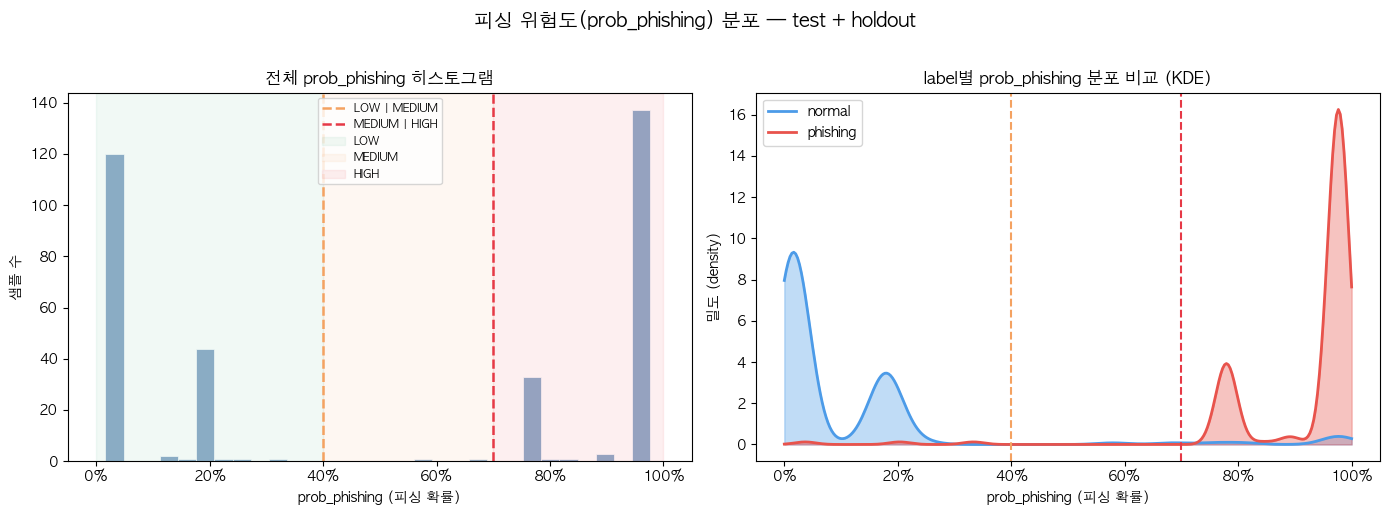

[Save] risk_distribution_fig1.png


In [14]:
# ── Fig 1: 히스토그램 + label별 KDE 비교 ─────────────────────────────────────
import matplotlib.ticker as mticker
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "피싱 위험도(prob_phishing) 분포 — test + holdout",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

probs_all = df_eval["prob_phishing"].values
probs_phishing = df_eval.loc[df_eval["label"] == "phishing", "prob_phishing"].values
probs_normal = df_eval.loc[df_eval["label"] == "normal", "prob_phishing"].values

ax = axes[0]
ax.hist(
    probs_all, bins=30, color="#7B9EC1", edgecolor="white", linewidth=0.6, alpha=0.85
)
for x, label, color in [
    (MEDIUM_LOWER, "LOW | MEDIUM", COLOR_MEDIUM),
    (HIGH_LOWER, "MEDIUM | HIGH", COLOR_HIGH),
]:
    ax.axvline(x, color=color, linewidth=1.8, linestyle="--", label=label)
ax.axvspan(0, MEDIUM_LOWER, alpha=0.08, color=COLOR_LOW, label="LOW")
ax.axvspan(MEDIUM_LOWER, HIGH_LOWER, alpha=0.08, color=COLOR_MEDIUM, label="MEDIUM")
ax.axvspan(HIGH_LOWER, 1.0, alpha=0.08, color=COLOR_HIGH, label="HIGH")
ax.set_title("전체 prob_phishing 히스토그램", fontsize=12)
ax.set_xlabel("prob_phishing (피싱 확률)")
ax.set_ylabel("샘플 수")
ax.legend(fontsize=8, loc="upper center")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

ax2 = axes[1]
for probs, label, color in [
    (probs_normal, "normal", COLOR_NORMAL),
    (probs_phishing, "phishing", COLOR_PHISHING),
]:
    kde = gaussian_kde(probs, bw_method=0.15)
    x_grid = np.linspace(0, 1, 300)
    ax2.fill_between(x_grid, kde(x_grid), alpha=0.35, color=color)
    ax2.plot(x_grid, kde(x_grid), color=color, linewidth=2, label=label)
for x, color in [(MEDIUM_LOWER, COLOR_MEDIUM), (HIGH_LOWER, COLOR_HIGH)]:
    ax2.axvline(x, color=color, linewidth=1.5, linestyle="--")
ax2.set_title("label별 prob_phishing 분포 비교 (KDE)", fontsize=12)
ax2.set_xlabel("prob_phishing (피싱 확률)")
ax2.set_ylabel("밀도 (density)")
ax2.legend(fontsize=10)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig("reports/figures/risk_distribution_fig1.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Save] reports/figures/risk_distribution_fig1.png")

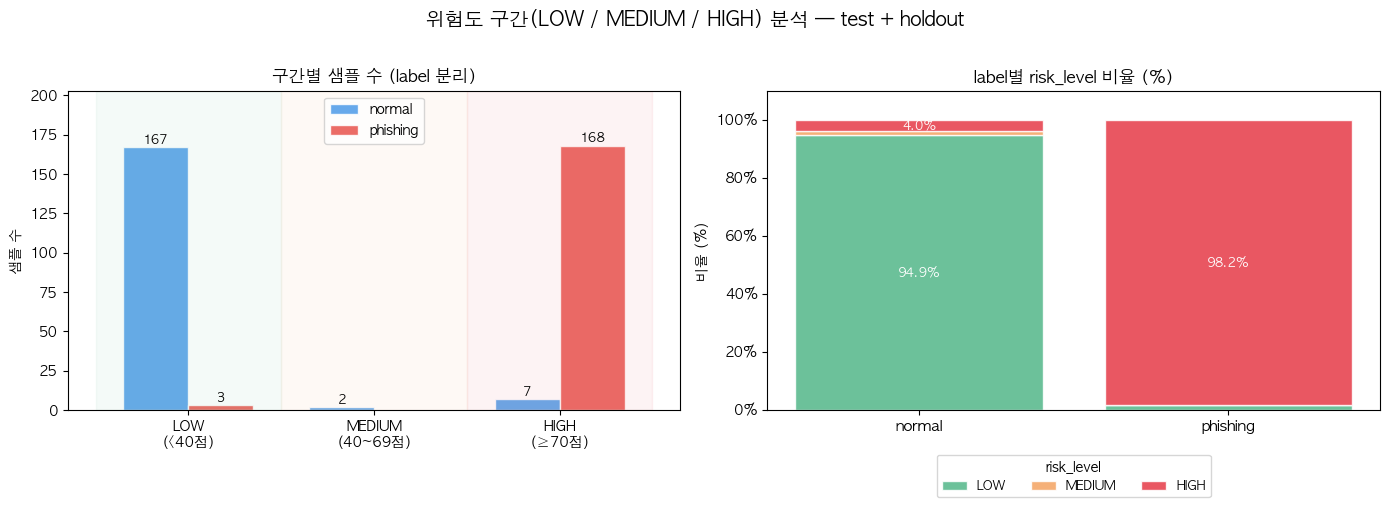

[Save] risk_distribution_fig2.png


In [15]:
# ── Fig 2: 구간별 샘플 수 + label별 비율 ─────────────────────────────────────
ct = pd.crosstab(df_eval["risk_level"], df_eval["label"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "위험도 구간(LOW / MEDIUM / HIGH) 분석 — test + holdout",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

levels = ["LOW", "MEDIUM", "HIGH"]
x, width = np.arange(len(levels)), 0.35

ax = axes[0]
bars_n = ax.bar(
    x - width / 2,
    [ct.loc[lv, "normal"] if lv in ct.index else 0 for lv in levels],
    width,
    label="normal",
    color=COLOR_NORMAL,
    alpha=0.85,
    edgecolor="white",
)
bars_p = ax.bar(
    x + width / 2,
    [ct.loc[lv, "phishing"] if lv in ct.index else 0 for lv in levels],
    width,
    label="phishing",
    color=COLOR_PHISHING,
    alpha=0.85,
    edgecolor="white",
)
for bar in [*bars_n, *bars_p]:
    h = bar.get_height()
    if h > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 1,
            str(int(h)),
            ha="center",
            va="bottom",
            fontsize=9,
        )
for pos, color in zip(x, [COLOR_LOW, COLOR_MEDIUM, COLOR_HIGH]):
    ax.axvspan(pos - 0.5, pos + 0.5, alpha=0.06, color=color)
ax.set_title("구간별 샘플 수 (label 분리)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(["LOW\n(<40점)", "MEDIUM\n(40~69점)", "HIGH\n(≥70점)"], fontsize=10)
ax.set_ylabel("샘플 수")
ax.legend(fontsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

ax2 = axes[1]
labels_order = ["normal", "phishing"]
x2 = np.arange(len(labels_order))
pct_by_label = (
    pd.crosstab(df_eval["label"], df_eval["risk_level"], normalize="index") * 100
)
for col in ["LOW", "MEDIUM", "HIGH"]:
    if col not in pct_by_label.columns:
        pct_by_label[col] = 0.0
bottom = np.zeros(len(labels_order))
for lv, color in [("LOW", COLOR_LOW), ("MEDIUM", COLOR_MEDIUM), ("HIGH", COLOR_HIGH)]:
    vals = [
        pct_by_label.loc[l, lv] if l in pct_by_label.index else 0 for l in labels_order
    ]
    bars = ax2.bar(
        x2, vals, bottom=bottom, label=lv, color=color, alpha=0.85, edgecolor="white"
    )
    for i, (bar, val) in enumerate(zip(bars, vals)):
        if val >= 3:
            ax2.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[i] + val / 2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="white",
            )
    bottom += np.array(vals)
ax2.set_title("label별 risk_level 비율 (%)", fontsize=12)
ax2.set_xticks(x2)
ax2.set_xticklabels(labels_order, fontsize=11)
ax2.set_ylabel("비율 (%)")
ax2.set_ylim(0, 110)
ax2.legend(
    title="risk_level",
    fontsize=9,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig("reports/figures/risk_distribution_fig2.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Save] reports/figures/risk_distribution_fig2.png")

In [16]:
# ── 콘솔 요약 ─────────────────────────────────────────────────────────────────
print("=" * 50)
print("[ 위험도 분포 요약 (test + holdout) ]")
print("=" * 50)
print(pd.crosstab(df_eval["risk_level"], df_eval["label"], margins=True))

print("\n[ label별 prob_phishing 통계 ]")
print(
    df_eval.groupby("label")["prob_phishing"]
    .agg(["mean", "median", "std", "min", "max"])
    .round(4)
)

print("\n[ 구간별 피싱 적중률 ]")
for lv in ["LOW", "MEDIUM", "HIGH"]:
    sub = df_eval[df_eval["risk_level"] == lv]
    if len(sub) == 0:
        continue
    phish_rate = (sub["label"] == "phishing").mean() * 100
    print(f"  {lv:6}: {len(sub):3}건 | 피싱 비율 {phish_rate:.1f}%")

[ 위험도 분포 요약 (test + holdout) ]
label       normal  phishing  All
risk_level                       
LOW            167         3  170
MEDIUM           2         0    2
HIGH             7       168  175
All            176       171  347

[ label별 prob_phishing 통계 ]
            mean  median     std     min     max
label                                           
normal    0.1042  0.0163  0.1928  0.0163  0.9768
phishing  0.9237  0.9768  0.1261  0.0366  0.9768

[ 구간별 피싱 적중률 ]
  LOW   : 170건 | 피싱 비율 1.8%
  MEDIUM:   2건 | 피싱 비율 0.0%
  HIGH  : 175건 | 피싱 비율 96.0%


## 2. 근거 피처 분석 (ComplementNB log-prob 차이)

`log P(feature|phishing) − log P(feature|normal)` — 양수면 피싱 특징적,
음수면 정상 특징적. 구조 피처 이름은 `ts.STRUCT_FEATURE_NAMES`를 그대로
가져와서 하드코딩 드리프트를 없앴습니다 (이전 버전은 6개를 노트북에 직접
나열해뒀는데, `train_sms.py` 쪽 피처가 늘어나면 순서가 어긋날 수 있었음).


In [17]:
N_TOP = 20

feature_names = list(vectorizer.get_feature_names_out()) + ts.STRUCT_FEATURE_NAMES

# CalibratedClassifierCV → 내부 base_estimator(ComplementNB) 추출
base_nb = model.calibrated_classifiers_[0].estimator
normal_idx_nb = list(base_nb.classes_).index("normal")
phishing_idx_nb = list(base_nb.classes_).index("phishing")

log_prob_normal = base_nb.feature_log_prob_[normal_idx_nb]
log_prob_phishing = base_nb.feature_log_prob_[phishing_idx_nb]
phishing_score = log_prob_phishing - log_prob_normal

top_phishing_idx = np.argsort(phishing_score)[::-1][:N_TOP]
top_normal_idx = np.argsort(phishing_score)[:N_TOP]

print(f"=== 피싱 판단 기여 상위 {N_TOP} 키워드 ===\n")
for rank, idx in enumerate(top_phishing_idx, 1):
    print(f"  {rank:2}. '{feature_names[idx]}'  (score={phishing_score[idx]:.4f})")

print(f"\n=== 정상 판단 기여 상위 {N_TOP} 키워드 ===\n")
for rank, idx in enumerate(top_normal_idx, 1):
    print(f"  {rank:2}. '{feature_names[idx]}'  (score={phishing_score[idx]:.4f})")

=== 피싱 판단 기여 상위 20 키워드 ===

   1. '대출'  (score=8.3443)
   2. ' 엄마'  (score=8.1533)
   3. '당첨'  (score=8.1533)
   4. ' 당첨'  (score=8.1533)
   5. '엄마'  (score=8.1533)
   6. '모님'  (score=8.0992)
   7. ' 장모'  (score=8.0992)
   8. '장모'  (score=8.0992)
   9. '장모님'  (score=8.0992)
  10. ' 장모님'  (score=8.0992)
  11. ' 이체'  (score=8.0711)
  12. '좌번'  (score=8.0123)
  13. '좌번호'  (score=8.0123)
  14. '계좌번'  (score=8.0123)
  15. '계좌번호'  (score=8.0123)
  16. '엄마 '  (score=8.0123)
  17. ' 엄마 '  (score=8.0123)
  18. '호) '  (score=7.9815)
  19. ' (계좌'  (score=7.9815)
  20. ' (계'  (score=7.9815)

=== 정상 판단 기여 상위 20 키워드 ===

   1. '주차'  (score=-8.3587)
   2. ' 답'  (score=-8.2505)
   3. '분 '  (score=-8.1917)
   4. '답장'  (score=-8.0964)
   5. ' 티'  (score=-8.0964)
   6. '뱅킹'  (score=-8.0275)
   7. '있음'  (score=-7.9911)
   8. ')로 '  (score=-7.9911)
   9. ' 있음'  (score=-7.9911)
  10. ')로'  (score=-7.9911)
  11. '티머'  (score=-7.9142)
  12. '티머니'  (score=-7.9142)
  13. ' 티머니'  (score=-7.9142)
  14. ' 티머'  (sc

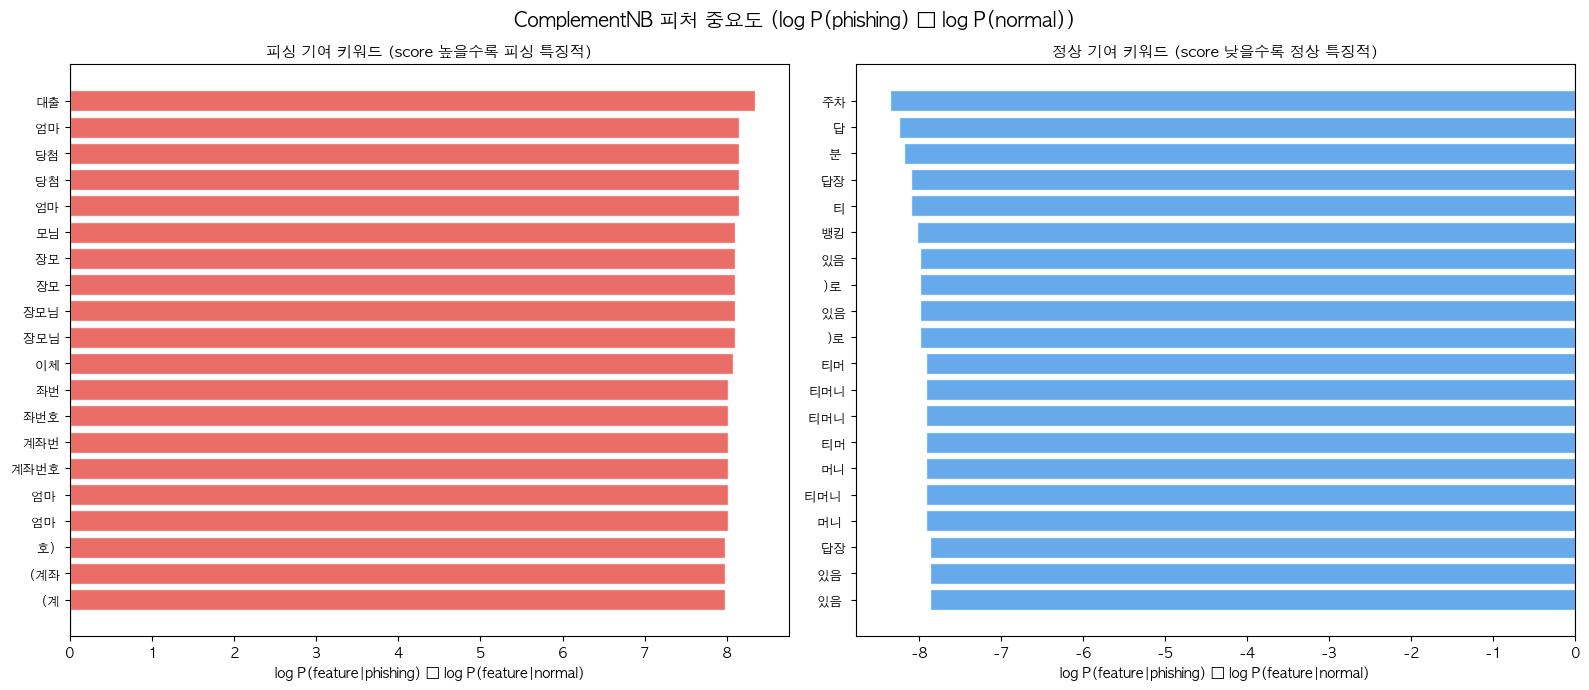

[Save] feature_importance.png


In [18]:
# ── 시각화 ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    "ComplementNB 피처 중요도 (log P(phishing) − log P(normal))",
    fontsize=14,
    fontweight="bold",
)

p_names = [feature_names[i] for i in top_phishing_idx]
p_scores = [phishing_score[i] for i in top_phishing_idx]
axes[0].barh(
    range(N_TOP), p_scores[::-1], color="#E8534C", alpha=0.85, edgecolor="white"
)
axes[0].set_yticks(range(N_TOP))
axes[0].set_yticklabels(p_names[::-1], fontsize=9)
axes[0].set_title("피싱 기여 키워드 (score 높을수록 피싱 특징적)", fontsize=11)
axes[0].set_xlabel("log P(feature|phishing) − log P(feature|normal)")
axes[0].axvline(0, color="black", linewidth=0.8)

n_names = [feature_names[i] for i in top_normal_idx]
n_scores = [phishing_score[i] for i in top_normal_idx]
axes[1].barh(
    range(N_TOP), n_scores[::-1], color="#4C9BE8", alpha=0.85, edgecolor="white"
)
axes[1].set_yticks(range(N_TOP))
axes[1].set_yticklabels(n_names[::-1], fontsize=9)
axes[1].set_title("정상 기여 키워드 (score 낮을수록 정상 특징적)", fontsize=11)
axes[1].set_xlabel("log P(feature|phishing) − log P(feature|normal)")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("reports/figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Save] reports/figures/feature_importance.png")